In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int

def adder(state:AgentState):
    """This function adds two numbers."""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state:AgentState):
    """This fuction subtracts two numbers."""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def decide_next_node(state:AgentState):
    """This node will select the next node of the graph based on the operation."""
    if state["operation"] == "+":
        return "addOperation" 
    elif state["operation"] == "-":
        return "subOperation"  
    
graph = StateGraph(AgentState)
graph.add_node("adderNode", adder)
graph.add_node("SubtractorNode", subtractor)
graph.add_node("router", lambda state:state) #passthrough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        #Edge: node name
        "addOperation": "adderNode",
        "subOperation": "SubtractorNode"    

    }
)
graph.add_edge("adderNode", END)
graph.add_edge("SubtractorNode", END)

app = graph.compile()


state1 = AgentState(number1 = 4, number2 = 8, operation="-")
result = app.invoke(state1)
print(result)











{'number1': 4, 'number2': 8, 'operation': '-', 'finalNumber': 12}


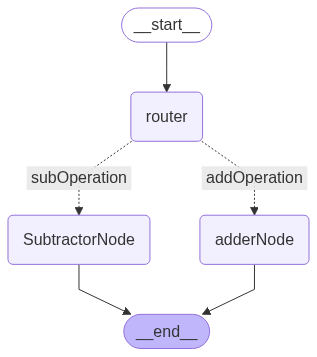

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))